# Assignment 2 Debug Notebook 2


In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import datasets, transforms

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Path('../results' if Path.cwd().name == 'debug' else 'results').mkdir(exist_ok=True)

print(f'cwd: {Path.cwd().resolve()}')
print(f"device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f'torch: {torch.__version__}')
print(f'cuda available: {torch.cuda.is_available()}')


cwd: /gpfs/home1/ahy0502/trustworthy-ai-assignment2
device: cuda
torch: 2.11.0+cu130
cuda available: True


## Step 1. Load CIFAR-10

데이터셋 다운로드와 기본 전처리가 정상 동작하는지 확인


test samples: 10000
sample shape: (3, 32, 32)
sample label: 3 (cat)
value range: [0.0510, 1.0000]


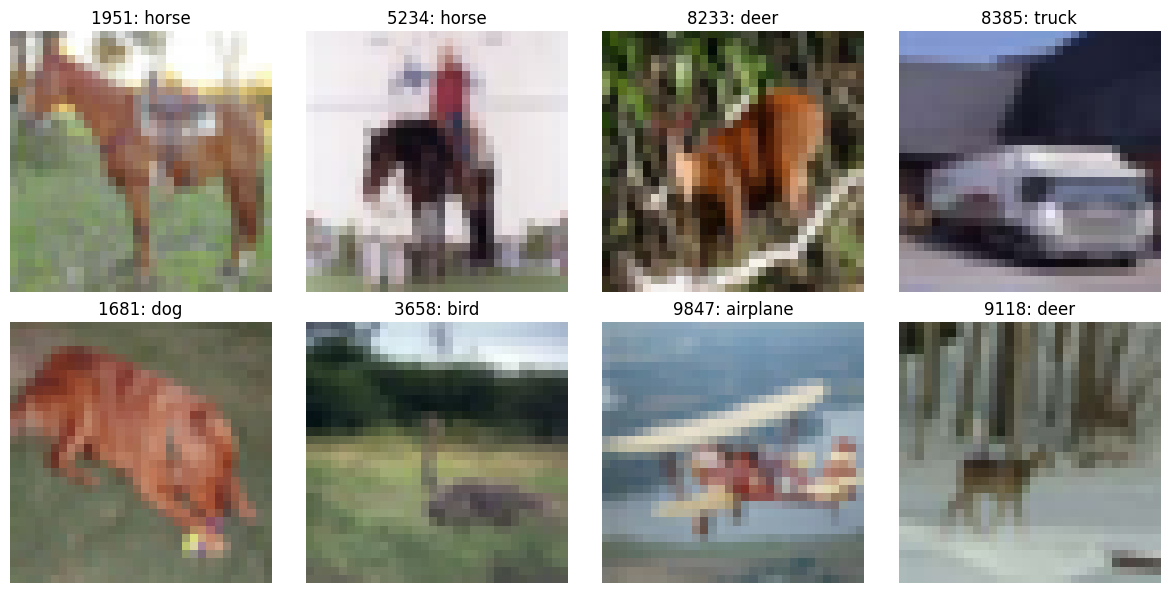

In [2]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck',
]

# img to tensor
# (H, W, C) in [0, 255] -> (C, H, W) in [0.0, 1.0]
debug_transform = transforms.ToTensor()

test_dataset = datasets.CIFAR10(
    root='../data' if Path.cwd().name == 'debug' else 'data',
    train=False,
    download=True,
    transform=debug_transform,
)

print(f'test samples: {len(test_dataset)}')
sample_img, sample_label = test_dataset[0]
print(f'sample shape: {tuple(sample_img.shape)}')
print(f'sample label: {sample_label} ({class_names[sample_label]})')
print(f'value range: [{sample_img.min().item():.4f}, {sample_img.max().item():.4f}]')
indices = random.sample(range(len(test_dataset)), 8)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, idx in zip(axes.flat, indices):
    image, label = test_dataset[idx]
    ax.imshow(image.permute(1, 2, 0).numpy())
    ax.set_title(f'{idx}: {class_names[label]}')
    ax.axis('off')

plt.tight_layout()
plt.show()


## Step 2. Build CIFAR-10 ResNet50 Models

`CIFAR-10` 입력 크기에 맞도록 기존 `ResNet50` 변경 및 확인


In [3]:
from torch import nn
from torch.utils.data import DataLoader
from torchvision.models import resnet50
from tqdm.auto import tqdm

cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2470, 0.2435, 0.2616)

# preprocess
model_input_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std),
])

# test dataset for model input
model_test_dataset = datasets.CIFAR10(
    root='../data' if Path.cwd().name == 'debug' else 'data',
    train=False,
    download=True,
    transform=model_input_transform,
)

model_test_loader = DataLoader(
    model_test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

# resnet50 for cifar10
def build_cifar10_resnet50(random_seed):
    torch.manual_seed(random_seed)
    cifar10_resnet50_model = resnet50(weights=None)
    # modification for cifar10
    cifar10_resnet50_model.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False,
    )
    cifar10_resnet50_model.maxpool = nn.Identity()
    cifar10_resnet50_model.fc = nn.Linear(
        in_features=cifar10_resnet50_model.fc.in_features,
        out_features=len(class_names),
    )
    if torch.cuda.is_available():
        cifar10_resnet50_model = cifar10_resnet50_model.cuda()
    return cifar10_resnet50_model

# diff seeds for diff models
model_random_seed_list = [2026, 2027]
model_name_list = ['resnet50_wo_aug', 'resnet50_w_aug']
resnet50_model_list = [build_cifar10_resnet50(seed) for seed in model_random_seed_list]

input_batch, label_batch = next(iter(model_test_loader))
if torch.cuda.is_available():
    input_batch = input_batch.cuda()

print(f'input batch shape: {tuple(input_batch.shape)}')
print(f'label batch shape: {tuple(label_batch.shape)}')

for model_name, resnet50_model in zip(model_name_list, resnet50_model_list):
    resnet50_model.eval()
    with torch.no_grad():
        output_logits = resnet50_model(input_batch)
    predicted_class_index_list = output_logits.argmax(dim=1)[:5].cpu().tolist()
    predicted_class_name_list = [class_names[index] for index in predicted_class_index_list]
    trainable_parameter_count = sum(parameter.numel() for parameter in resnet50_model.parameters())
    print(f'\n{model_name}')
    print(f'logits shape: {tuple(output_logits.shape)}')
    print(f'trainable parameter count: {trainable_parameter_count:,}')
    print(f'first 5 predicted classes: {predicted_class_name_list}')


input batch shape: (16, 3, 32, 32)
label batch shape: (16,)

resnet50_wo_aug
logits shape: (16, 10)
trainable parameter count: 23,520,842
first 5 predicted classes: ['deer', 'deer', 'deer', 'deer', 'deer']

resnet50_w_aug
logits shape: (16, 10)
trainable parameter count: 23,520,842
first 5 predicted classes: ['airplane', 'airplane', 'airplane', 'airplane', 'airplane']


## Step 3. Split Training Settings

`test` preprocessing은 동일하게 유지하고, `train`에서는 한 모델은 augmentation 없이, 다른 모델은 augmentation을 적용


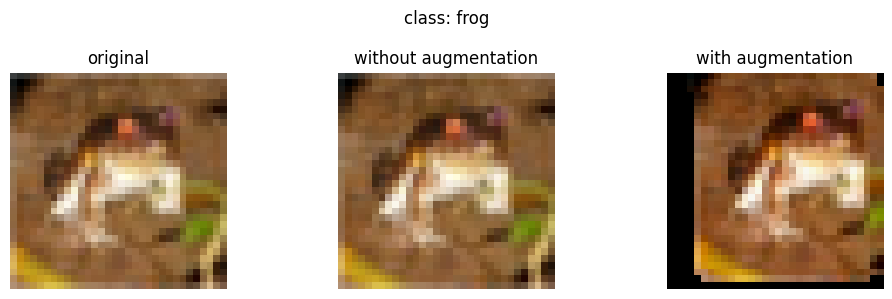

train samples without augmentation: 50000
train samples with augmentation: 50000
train batch shape without augmentation: (128, 3, 32, 32)
train batch shape with augmentation: (128, 3, 32, 32)


In [4]:
def unnormalize_image(normalized_image_tensor):
    mean_tensor = torch.tensor(cifar10_mean).view(3, 1, 1)
    std_tensor = torch.tensor(cifar10_std).view(3, 1, 1)
    restored_image_tensor = normalized_image_tensor.cpu() * std_tensor + mean_tensor
    return restored_image_tensor.clamp(0.0, 1.0)

# wo/ aug
train_transform_wo_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std),
])

# w/ aug
# random crop, color jitter, random rotation
train_transform_w_aug = transforms.Compose([
    transforms.RandomCrop(size=32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.RandomRotation(degrees=12),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std),
])

train_dataset_wo_aug = datasets.CIFAR10(
    root='../data' if Path.cwd().name == 'debug' else 'data',
    train=True,
    download=True,
    transform=train_transform_wo_aug,
)

train_dataset_w_aug = datasets.CIFAR10(
    root='../data' if Path.cwd().name == 'debug' else 'data',
    train=True,
    download=True,
    transform=train_transform_w_aug,
)

train_loader_wo_aug = DataLoader(
    train_dataset_wo_aug,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

train_loader_w_aug = DataLoader(
    train_dataset_w_aug,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

raw_train_dataset = datasets.CIFAR10(
    root='../data' if Path.cwd().name == 'debug' else 'data',
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

sample_index = 0
original_image_tensor, original_label_index = raw_train_dataset[sample_index]
image_wo_aug, _ = train_dataset_wo_aug[sample_index]
image_w_aug, _ = train_dataset_w_aug[sample_index]

figure, axis_list = plt.subplots(1, 3, figsize=(10, 3))
axis_list[0].imshow(original_image_tensor.permute(1, 2, 0).numpy())
axis_list[0].set_title('original')
axis_list[1].imshow(unnormalize_image(image_wo_aug).permute(1, 2, 0).numpy())
axis_list[1].set_title('without augmentation')
axis_list[2].imshow(unnormalize_image(image_w_aug).permute(1, 2, 0).numpy())
axis_list[2].set_title('with augmentation')

for axis in axis_list:
    axis.axis('off')

plt.suptitle(f'class: {class_names[original_label_index]}')
plt.tight_layout()
plt.show()

print(f'train samples without augmentation: {len(train_dataset_wo_aug)}')
print(f'train samples with augmentation: {len(train_dataset_w_aug)}')

train_input_batch_wo_aug, train_label_batch_wo_aug = next(iter(train_loader_wo_aug))
train_input_batch_w_aug, train_label_batch_w_aug = next(iter(train_loader_w_aug))

print(f'train batch shape without augmentation: {tuple(train_input_batch_wo_aug.shape)}')
print(f'train batch shape with augmentation: {tuple(train_input_batch_w_aug.shape)}')

## Step 4. Build Training Loop

학습 구성


In [5]:
Path('../ckpts' if Path.cwd().name == 'debug' else 'ckpts').mkdir(exist_ok=True)

# hyperparameters
val_ratio = 0.1
training_epoch_count = 20
training_learning_rate = 0.1
training_momentum = 0.9
training_weight_decay = 5e-4

# True: start training
# False: sanity check
run_training_now = False

split_random_generator = torch.Generator().manual_seed(SEED)
all_train_index_tensor = torch.randperm(len(train_dataset_wo_aug), generator=split_random_generator)
val_sample_count = int(len(all_train_index_tensor) * val_ratio)
val_index_list = all_train_index_tensor[:val_sample_count].tolist()
train_index_list = all_train_index_tensor[val_sample_count:].tolist()

train_subset_wo_aug = torch.utils.data.Subset(train_dataset_wo_aug, train_index_list)
train_subset_w_aug = torch.utils.data.Subset(train_dataset_w_aug, train_index_list)

val_dataset = datasets.CIFAR10(
    root='../data' if Path.cwd().name == 'debug' else 'data',
    train=True,
    download=True,
    transform=model_input_transform,
)
val_subset = torch.utils.data.Subset(val_dataset, val_index_list)

train_loader_wo_aug = DataLoader(
    train_subset_wo_aug,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

train_loader_w_aug = DataLoader(
    train_subset_w_aug,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_subset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

def cal_acc(output_logits, label_index_tensor):
    predicted_label_index_tensor = output_logits.argmax(dim=1)
    correct_prediction_count = (predicted_label_index_tensor == label_index_tensor).sum().item()
    sample_count = label_index_tensor.size(0)
    return correct_prediction_count / sample_count

def train_one_epoch(model_name, resnet50_model, train_loader, loss_function, optimizer):
    resnet50_model.train()
    loss_sum = 0.0
    accuracy_sum = 0.0
    batch_count = 0

    train_progress_bar = tqdm(
        train_loader,
        desc=f'{model_name} train',
        leave=False,
        dynamic_ncols=True,
    )

    for input_batch, label_batch in train_progress_bar:
        if torch.cuda.is_available():
            input_batch = input_batch.cuda(non_blocking=True)
            label_batch = label_batch.cuda(non_blocking=True)

        optimizer.zero_grad()
        output_logits = resnet50_model(input_batch)
        loss_value = loss_function(output_logits, label_batch)
        loss_value.backward()
        optimizer.step()

        loss_sum += loss_value.item()
        accuracy_sum += cal_acc(output_logits, label_batch)
        batch_count += 1
        train_progress_bar.set_postfix(
            loss=f'{loss_sum / batch_count:.4f}',
            acc=f'{accuracy_sum / batch_count:.4f}',
        )

    return loss_sum / batch_count, accuracy_sum / batch_count

def eval_model(model_name, resnet50_model, eval_loader, loss_function):
    resnet50_model.eval()
    loss_sum = 0.0
    accuracy_sum = 0.0
    batch_count = 0

    eval_progress_bar = tqdm(
        eval_loader,
        desc=f'{model_name} eval',
        leave=False,
        dynamic_ncols=True,
    )

    with torch.no_grad():
        for input_batch, label_batch in eval_progress_bar:
            if torch.cuda.is_available():
                input_batch = input_batch.cuda(non_blocking=True)
                label_batch = label_batch.cuda(non_blocking=True)

            output_logits = resnet50_model(input_batch)
            loss_value = loss_function(output_logits, label_batch)

            loss_sum += loss_value.item()
            accuracy_sum += cal_acc(output_logits, label_batch)
            batch_count += 1
            eval_progress_bar.set_postfix(
                loss=f'{loss_sum / batch_count:.4f}',
                acc=f'{accuracy_sum / batch_count:.4f}',
            )

    return loss_sum / batch_count, accuracy_sum / batch_count

def train_model(model_name, resnet50_model, train_loader, val_loader):
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        resnet50_model.parameters(),
        lr=training_learning_rate,
        momentum=training_momentum,
        weight_decay=training_weight_decay,
    )
    learning_rate_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=training_epoch_count,
    )
    checkpoint_path = Path('../ckpts' if Path.cwd().name == 'debug' else 'ckpts') / f'{model_name}.pt'
    training_history_list = []
    best_val_accuracy = -1.0

    epoch_progress_bar = tqdm(
        range(training_epoch_count),
        desc=f'{model_name} epochs',
        leave=True,
        dynamic_ncols=True,
    )

    for epoch_index in epoch_progress_bar:
        train_loss, train_accuracy = train_one_epoch(
            model_name,
            resnet50_model,
            train_loader,
            loss_function,
            optimizer,
        )
        val_loss, val_accuracy = eval_model(
            model_name,
            resnet50_model,
            val_loader,
            loss_function,
        )
        learning_rate_scheduler.step()

        epoch_result = {
            'epoch': epoch_index + 1,
            'train_loss': train_loss,
            'train_accuracy': train_accuracy,
            'val_loss': val_loss,
            'val_accuracy': val_accuracy,
        }
        training_history_list.append(epoch_result)
        epoch_progress_bar.set_postfix(
            train_loss=f'{train_loss:.4f}',
            train_acc=f'{train_accuracy:.4f}',
            val_loss=f'{val_loss:.4f}',
            val_acc=f'{val_accuracy:.4f}',
        )

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(
                {
                    'model_name': model_name,
                    'model_state_dict': resnet50_model.state_dict(),
                    'epoch': epoch_index + 1,
                    'val_accuracy': val_accuracy,
                },
                checkpoint_path,
            )

        print(
            f"{model_name} | epoch {epoch_index + 1:02d}/{training_epoch_count} | "
            f"train loss {train_loss:.4f} | train acc {train_accuracy:.4f} | "
            f"val loss {val_loss:.4f} | val acc {val_accuracy:.4f}"
        )

    return training_history_list, checkpoint_path

training_setup_list = [
    {
        'model_name': 'resnet50_wo_aug',
        'resnet50_model': resnet50_model_list[0],
        'train_loader': train_loader_wo_aug,
    },
    {
        'model_name': 'resnet50_w_aug',
        'resnet50_model': resnet50_model_list[1],
        'train_loader': train_loader_w_aug,
    },
]

print(f'train split size: {len(train_index_list)}')
print(f'val split size: {len(val_index_list)}')
print(f"ckpts dir: {'../ckpts' if Path.cwd().name == 'debug' else 'ckpts'}")

if run_training_now:
    training_result_dict = {}
    for training_setup in training_setup_list:
        training_history_list, checkpoint_path = train_model(
            model_name=training_setup['model_name'],
            resnet50_model=training_setup['resnet50_model'],
            train_loader=training_setup['train_loader'],
            val_loader=val_loader,
        )
        training_result_dict[training_setup['model_name']] = {
            'history': training_history_list,
            'checkpoint_path': checkpoint_path,
        }
else:
    print('training loop ready')
    print('set run_training_now = True to start training')


train split size: 45000
val split size: 5000
ckpts dir: ckpts
training loop ready
set run_training_now = True to start training


## Step 5. Load Ckpts And Compare Clean Test Results

저장된 checkpoint를 다시 불러와 `test accuracy`와 `clean disagreement`를 확인


resnet50_wo_aug eval:   0%|                                                                                   …

resnet50_wo_aug | saved epoch 20 | val acc 0.8387 | test loss 0.7445 | test acc 0.8276


resnet50_w_aug eval:   0%|                                                                                    …

resnet50_w_aug | saved epoch 20 | val acc 0.8279 | test loss 0.5206 | test acc 0.8227


resnet50_wo_aug predict:   0%|                                                                                …

resnet50_w_aug predict:   0%|                                                                                 …

clean disagreement count: 1883
clean disagreement rate: 0.1883


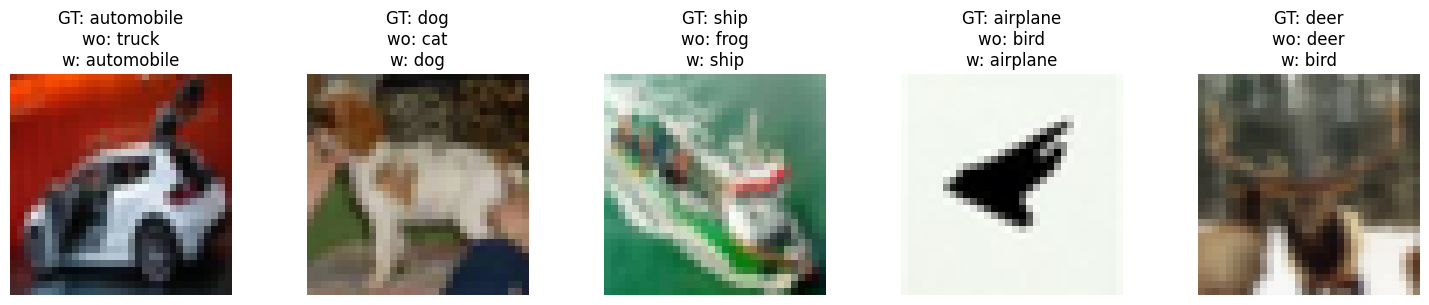

In [6]:
def load_trained_resnet50(model_name, random_seed):
    trained_resnet50_model = build_cifar10_resnet50(random_seed)
    checkpoint = torch.load(
        Path('../ckpts' if Path.cwd().name == 'debug' else 'ckpts') / f'{model_name}.pt',
        map_location='cuda' if torch.cuda.is_available() else 'cpu',
    )
    trained_resnet50_model.load_state_dict(checkpoint['model_state_dict'])
    trained_resnet50_model.eval()
    return trained_resnet50_model, checkpoint

def collect_prediction_tensor(model_name, resnet50_model, data_loader):
    predicted_label_index_tensor_list = []
    true_label_index_tensor_list = []

    prediction_progress_bar = tqdm(
        data_loader,
        desc=f'{model_name} predict',
        leave=False,
        dynamic_ncols=True,
    )

    with torch.no_grad():
        for input_batch, label_batch in prediction_progress_bar:
            if torch.cuda.is_available():
                input_batch = input_batch.cuda(non_blocking=True)

            output_logits = resnet50_model(input_batch)
            predicted_label_index_tensor_list.append(output_logits.argmax(dim=1).cpu())
            true_label_index_tensor_list.append(label_batch.cpu())

    return torch.cat(predicted_label_index_tensor_list), torch.cat(true_label_index_tensor_list)

test_loss_function = nn.CrossEntropyLoss()
trained_model_list = []

for model_name, random_seed in zip(model_name_list, model_random_seed_list):
    trained_resnet50_model, checkpoint = load_trained_resnet50(model_name, random_seed)
    trained_model_list.append(trained_resnet50_model)
    test_loss, test_accuracy = eval_model(
        model_name,
        trained_resnet50_model,
        model_test_loader,
        test_loss_function,
    )
    print(
        f"{model_name} | saved epoch {checkpoint['epoch']} | "
        f"val acc {checkpoint['validation_accuracy']:.4f} | "
        f"test loss {test_loss:.4f} | test acc {test_accuracy:.4f}"
    )

predicted_label_index_tensor_for_wo_aug, true_label_index_tensor = collect_prediction_tensor(
    'resnet50_wo_aug',
    trained_model_list[0],
    model_test_loader,
)

predicted_label_index_tensor_for_w_aug, _ = collect_prediction_tensor(
    'resnet50_w_aug',
    trained_model_list[1],
    model_test_loader,
)

disagreement_index_list = torch.nonzero(
    predicted_label_index_tensor_for_wo_aug != predicted_label_index_tensor_for_w_aug,
    as_tuple=False,
).view(-1).tolist()

print(f'clean disagreement count: {len(disagreement_index_list)}')
print(f'clean disagreement rate: {len(disagreement_index_list) / len(model_test_dataset):.4f}')

raw_test_dataset = datasets.CIFAR10(
    root='../data' if Path.cwd().name == 'debug' else 'data',
    train=False,
    download=True,
    transform=transforms.ToTensor(),
)

disagreement_example_count = min(5, len(disagreement_index_list))

if disagreement_example_count > 0:
    figure, axis_list = plt.subplots(1, disagreement_example_count, figsize=(3 * disagreement_example_count, 3))
    if disagreement_example_count == 1:
        axis_list = [axis_list]

    for axis, disagreement_index in zip(axis_list, disagreement_index_list[:disagreement_example_count]):
        image_tensor, true_label_index = raw_test_dataset[disagreement_index]
        predicted_label_index_for_wo_aug = predicted_label_index_tensor_for_wo_aug[disagreement_index].item()
        predicted_label_index_for_w_aug = predicted_label_index_tensor_for_w_aug[disagreement_index].item()

        axis.imshow(image_tensor.permute(1, 2, 0).numpy())
        axis.set_title(
            f'GT: {class_names[true_label_index]}\n'
            f'wo: {class_names[predicted_label_index_for_wo_aug]}\n'
            f'w: {class_names[predicted_label_index_for_w_aug]}'
        )
        axis.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('clean disagreement example not found')


## Step 6. Measure Neuron Coverage On Clean Test Inputs

이 노트북은 속도 확인용으로 벡터화된 coverage 계산 버전 사용 단계임


In [7]:
coverage_activation_threshold = 0.2
coverage_batch_size = 128
coverage_batch_limit = None

coverage_test_loader = DataLoader(
    model_test_dataset,
    batch_size=coverage_batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


def build_layer_name_list_for_coverage(resnet50_model):
    layer_name_list = []
    for layer_name, layer_module in resnet50_model.named_modules():
        if isinstance(layer_module, (nn.Conv2d, nn.Linear)):
            layer_name_list.append(layer_name)
    return layer_name_list


def normalize_neuron_activation(neuron_activation_tensor):
    minimum_activation = neuron_activation_tensor.min(dim=1, keepdim=True).values
    maximum_activation = neuron_activation_tensor.max(dim=1, keepdim=True).values
    return (neuron_activation_tensor - minimum_activation) / (maximum_activation - minimum_activation + 1e-6)


def measure_neuron_coverage(model_name, resnet50_model, data_loader, activation_threshold, batch_limit=None):
    covered_neuron_dict = {}
    hook_handle_list = []

    for layer_name, layer_module in resnet50_model.named_modules():
        if isinstance(layer_module, nn.Conv2d):
            covered_neuron_dict[layer_name] = torch.zeros(layer_module.out_channels, dtype=torch.bool)

            def conv_hook(module, input_value, output_value, layer_name=layer_name):
                neuron_activation_tensor = output_value.detach().float().mean(dim=(2, 3)).cpu()
                normalized_neuron_activation_tensor = normalize_neuron_activation(neuron_activation_tensor)
                covered_neuron_dict[layer_name] |= (normalized_neuron_activation_tensor > activation_threshold).any(dim=0)

            hook_handle_list.append(layer_module.register_forward_hook(conv_hook))

        if isinstance(layer_module, nn.Linear):
            covered_neuron_dict[layer_name] = torch.zeros(layer_module.out_features, dtype=torch.bool)

            def linear_hook(module, input_value, output_value, layer_name=layer_name):
                neuron_activation_tensor = output_value.detach().float().cpu()
                normalized_neuron_activation_tensor = normalize_neuron_activation(neuron_activation_tensor)
                covered_neuron_dict[layer_name] |= (normalized_neuron_activation_tensor > activation_threshold).any(dim=0)

            hook_handle_list.append(layer_module.register_forward_hook(linear_hook))

    resnet50_model.eval()
    coverage_progress_bar = tqdm(
        data_loader,
        desc=f'{model_name} coverage',
        leave=False,
        dynamic_ncols=True,
    )

    with torch.no_grad():
        for batch_index, (input_batch, _) in enumerate(coverage_progress_bar):
            if batch_limit is not None and batch_index >= batch_limit:
                break

            if torch.cuda.is_available():
                input_batch = input_batch.cuda(non_blocking=True)

            _ = resnet50_model(input_batch)

    for hook_handle in hook_handle_list:
        hook_handle.remove()

    covered_neuron_count = sum(covered_neuron_tensor.sum().item() for covered_neuron_tensor in covered_neuron_dict.values())
    total_neuron_count = sum(covered_neuron_tensor.numel() for covered_neuron_tensor in covered_neuron_dict.values())
    neuron_coverage_ratio = covered_neuron_count / total_neuron_count
    return covered_neuron_dict, covered_neuron_count, total_neuron_count, neuron_coverage_ratio


coverage_result_dict = {}

for model_name, trained_resnet50_model in zip(model_name_list, trained_model_list):
    covered_neuron_dict, covered_neuron_count, total_neuron_count, neuron_coverage_ratio = measure_neuron_coverage(
        model_name,
        trained_resnet50_model,
        coverage_test_loader,
        coverage_activation_threshold,
        coverage_batch_limit,
    )
    coverage_result_dict[model_name] = {
        'covered_neuron_dict': covered_neuron_dict,
        'covered_neuron_count': covered_neuron_count,
        'total_neuron_count': total_neuron_count,
        'neuron_coverage_ratio': neuron_coverage_ratio,
    }
    print(
        f"{model_name} | covered neurons {covered_neuron_count}/{total_neuron_count} | "
        f"neuron coverage {neuron_coverage_ratio:.4f}"
    )

average_neuron_coverage = sum(
    coverage_result_dict[model_name]['neuron_coverage_ratio']
    for model_name in model_name_list
) / len(model_name_list)

print(f'average neuron coverage: {average_neuron_coverage:.4f}')



resnet50_wo_aug coverage:   0%|                                                                               …

resnet50_wo_aug | covered neurons 26530/26570 | neuron coverage 0.9985


resnet50_w_aug coverage:   0%|                                                                                …

resnet50_w_aug | covered neurons 26315/26570 | neuron coverage 0.9904
average neuron coverage: 0.9944


## Step 7. Generate Disagreement-Inducing Inputs

이 단계는 벡터화 coverage 결과를 바탕으로 disagreement input을 생성하는 단계임


generate disagreement:   0%|                                                                                  …

target model: resnet50_wo_aug
target neuron: layer1.2.conv2[58]
generated disagreement count: 5


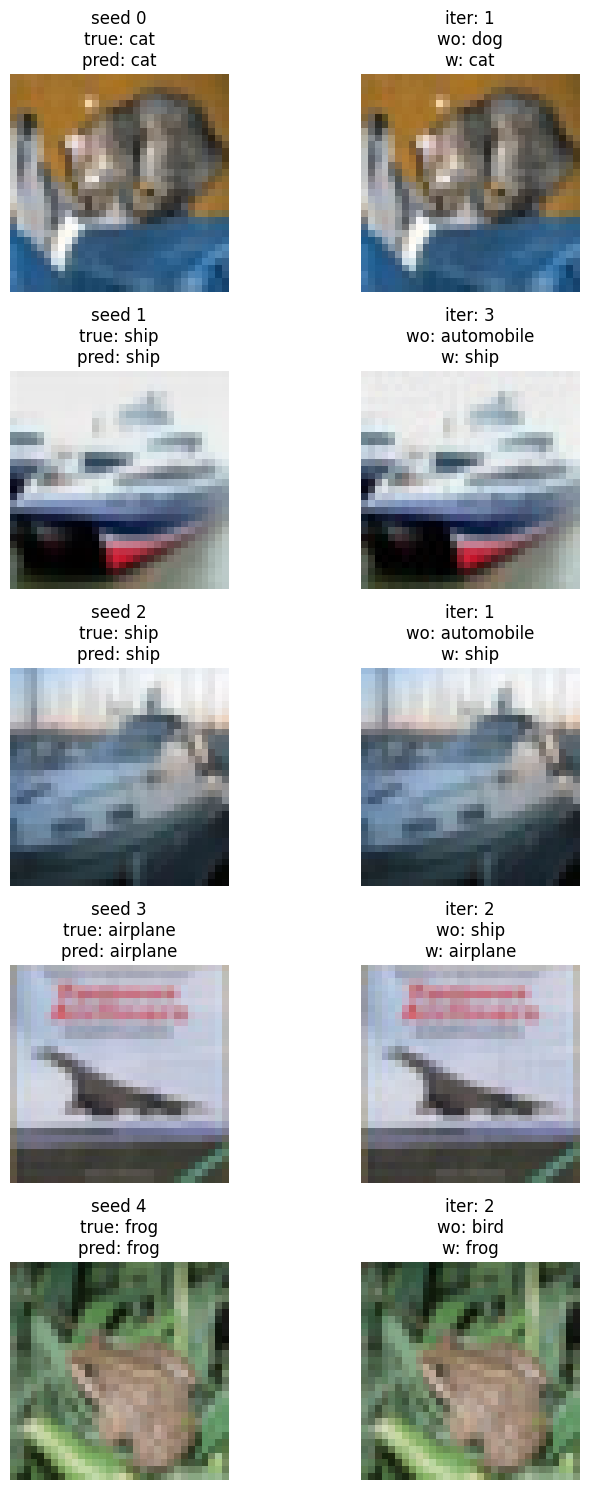

In [8]:
generation_target_model_index = 0
generation_seed_limit = 200
generation_iteration_count = 20
generation_step_size = 1 / 255
generation_max_perturbation = 8 / 255
generation_coverage_weight = 0.1
generation_target_count = 5


def normalize_image_for_model(image_tensor):
    mean_tensor = image_tensor.new_tensor(cifar10_mean).view(3, 1, 1)
    std_tensor = image_tensor.new_tensor(cifar10_std).view(3, 1, 1)
    return (image_tensor - mean_tensor) / std_tensor


def find_uncovered_neuron(covered_neuron_dict):
    for layer_name, covered_neuron_tensor in covered_neuron_dict.items():
        uncovered_neuron_index_tensor = torch.nonzero(~covered_neuron_tensor, as_tuple=False).view(-1)
        if uncovered_neuron_index_tensor.numel() > 0:
            return layer_name, uncovered_neuron_index_tensor[0].item()
    last_layer_name = list(covered_neuron_dict.keys())[-1]
    return last_layer_name, 0


def forward_with_target_neuron(resnet50_model, normalized_input_batch, target_layer_name, target_neuron_index):
    captured_output_dict = {}

    def save_output_hook(module, input_value, output_value):
        captured_output_dict['target_layer_output'] = output_value

    target_layer_module = dict(resnet50_model.named_modules())[target_layer_name]
    hook_handle = target_layer_module.register_forward_hook(save_output_hook)
    output_logits = resnet50_model(normalized_input_batch)
    hook_handle.remove()

    target_layer_output = captured_output_dict['target_layer_output']
    if target_layer_output.dim() == 4:
        target_neuron_activation = target_layer_output[:, target_neuron_index].mean()
    else:
        target_neuron_activation = target_layer_output[:, target_neuron_index].mean()

    return output_logits, target_neuron_activation


def predict_label_index_list(trained_model_list, image_tensor):
    normalized_input_batch = normalize_image_for_model(image_tensor.unsqueeze(0))
    with torch.no_grad():
        return [
            trained_resnet50_model(normalized_input_batch).argmax(dim=1).item()
            for trained_resnet50_model in trained_model_list
        ]


def generate_disagreement_input(seed_image_tensor, trained_model_list, target_model_index, target_layer_name, target_neuron_index):
    if torch.cuda.is_available():
        original_image_tensor = seed_image_tensor.clone().cuda()
    else:
        original_image_tensor = seed_image_tensor.clone()

    generated_image_tensor = original_image_tensor.clone()
    original_prediction_index_list = predict_label_index_list(trained_model_list, original_image_tensor)

    if original_prediction_index_list[0] != original_prediction_index_list[1]:
        return None

    original_prediction_index = original_prediction_index_list[0]
    other_model_index = 1 - target_model_index

    for iteration_index in range(generation_iteration_count):
        generated_image_tensor = generated_image_tensor.detach().requires_grad_(True)
        normalized_input_batch = normalize_image_for_model(generated_image_tensor.unsqueeze(0))

        target_model_logits, target_neuron_activation = forward_with_target_neuron(
            trained_model_list[target_model_index],
            normalized_input_batch,
            target_layer_name,
            target_neuron_index,
        )
        other_model_logits = trained_model_list[other_model_index](normalized_input_batch)

        disagreement_loss = (
            -target_model_logits[0, original_prediction_index]
            + other_model_logits[0, original_prediction_index]
        )
        total_loss = disagreement_loss + generation_coverage_weight * target_neuron_activation
        total_loss.backward()

        gradient_tensor = generated_image_tensor.grad.detach()
        normalized_gradient_tensor = gradient_tensor / (gradient_tensor.abs().mean() + 1e-8)

        with torch.no_grad():
            generated_image_tensor = generated_image_tensor + generation_step_size * normalized_gradient_tensor.sign()
            lower_bound_tensor = (original_image_tensor - generation_max_perturbation).clamp(0.0, 1.0)
            upper_bound_tensor = (original_image_tensor + generation_max_perturbation).clamp(0.0, 1.0)
            generated_image_tensor = torch.max(torch.min(generated_image_tensor, upper_bound_tensor), lower_bound_tensor)
            generated_image_tensor = generated_image_tensor.clamp(0.0, 1.0)

        generated_prediction_index_list = predict_label_index_list(trained_model_list, generated_image_tensor)
        if generated_prediction_index_list[0] != generated_prediction_index_list[1]:
            return {
                'generated_image_tensor': generated_image_tensor.detach().cpu(),
                'original_image_tensor': original_image_tensor.detach().cpu(),
                'original_prediction_index_list': original_prediction_index_list,
                'generated_prediction_index_list': generated_prediction_index_list,
                'iteration_index': iteration_index + 1,
            }

    return None


Path('../results/generated_inputs' if Path.cwd().name == 'debug' else 'results/generated_inputs').mkdir(parents=True, exist_ok=True)

target_model_name = model_name_list[generation_target_model_index]
target_layer_name, target_neuron_index = find_uncovered_neuron(
    coverage_result_dict[target_model_name]['covered_neuron_dict']
)

agreement_index_list = torch.nonzero(
    predicted_label_index_tensor_for_wo_aug == predicted_label_index_tensor_for_w_aug,
    as_tuple=False,
).view(-1).tolist()

generated_result_list = []
generation_progress_bar = tqdm(
    agreement_index_list[:generation_seed_limit],
    desc='generate disagreement',
    leave=False,
    dynamic_ncols=True,
)

print(f'target model: {target_model_name}')
print(f'target neuron: {target_layer_name}[{target_neuron_index}]')

for disagreement_seed_index in generation_progress_bar:
    seed_image_tensor, true_label_index = raw_test_dataset[disagreement_seed_index]
    generation_result = generate_disagreement_input(
        seed_image_tensor,
        trained_model_list,
        generation_target_model_index,
        target_layer_name,
        target_neuron_index,
    )

    if generation_result is None:
        continue

    generation_result['seed_index'] = disagreement_seed_index
    generation_result['true_label_index'] = true_label_index
    generated_result_list.append(generation_result)
    generation_progress_bar.set_postfix(found=len(generated_result_list))

    if len(generated_result_list) >= generation_target_count:
        break

print(f'generated disagreement count: {len(generated_result_list)}')

if len(generated_result_list) > 0:
    figure, axis_grid = plt.subplots(len(generated_result_list), 2, figsize=(8, 3 * len(generated_result_list)))
    if len(generated_result_list) == 1:
        axis_grid = np.expand_dims(axis_grid, axis=0)

    for result_index, generation_result in enumerate(generated_result_list):
        original_axis = axis_grid[result_index, 0]
        generated_axis = axis_grid[result_index, 1]

        original_axis.imshow(generation_result['original_image_tensor'].permute(1, 2, 0).numpy())
        original_axis.set_title(
            f"seed {generation_result['seed_index']}\n"
            f"true: {class_names[generation_result['true_label_index']]}\n"
            f"pred: {class_names[generation_result['original_prediction_index_list'][0]]}"
        )
        original_axis.axis('off')

        generated_axis.imshow(generation_result['generated_image_tensor'].permute(1, 2, 0).numpy())
        generated_axis.set_title(
            f"iter: {generation_result['iteration_index']}\n"
            f"wo: {class_names[generation_result['generated_prediction_index_list'][0]]}\n"
            f"w: {class_names[generation_result['generated_prediction_index_list'][1]]}"
        )
        generated_axis.axis('off')

        save_figure, save_axis_list = plt.subplots(1, 2, figsize=(6, 3))
        save_axis_list[0].imshow(generation_result['original_image_tensor'].permute(1, 2, 0).numpy())
        save_axis_list[0].set_title(
            f"seed {generation_result['seed_index']}\n"
            f"true: {class_names[generation_result['true_label_index']]}\n"
            f"pred: {class_names[generation_result['original_prediction_index_list'][0]]}"
        )
        save_axis_list[0].axis('off')
        save_axis_list[1].imshow(generation_result['generated_image_tensor'].permute(1, 2, 0).numpy())
        save_axis_list[1].set_title(
            f"iter: {generation_result['iteration_index']}\n"
            f"wo: {class_names[generation_result['generated_prediction_index_list'][0]]}\n"
            f"w: {class_names[generation_result['generated_prediction_index_list'][1]]}"
        )
        save_axis_list[1].axis('off')
        save_figure.tight_layout()
        save_figure.savefig(
            Path('../results/generated_inputs' if Path.cwd().name == 'debug' else 'results/generated_inputs') / f"generated_{result_index:02d}.png",
            bbox_inches='tight',
        )
        plt.close(save_figure)

    plt.tight_layout()
    plt.show()
else:
    print('generated disagreement example not found')

